# MASKED AUTOENCODER (MAE) — Self-Supervised Image Representation Learning
**Course:** Generative AI | **Assignment:** No. 2 | **Semester:** Spring 2026

By Bushra Abad and Tayyaba Imtiyaz

---
# 1. ENVIRONMENT SETUP

In [1]:
!pip install einops gradio torchmetrics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.7 MB/s eta 0:00:00


In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

from einops import rearrange
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from tqdm import tqdm

In [3]:
# ── Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── Image / Patch settings
IMAGE_SIZE      = 224
PATCH_SIZE      = 16
NUM_PATCHES     = (IMAGE_SIZE // PATCH_SIZE) ** 2   # 196
PATCH_DIM       = PATCH_SIZE * PATCH_SIZE * 3        # 768
MASK_RATIO      = 0.75
VISIBLE_PATCHES = int(NUM_PATCHES * (1 - MASK_RATIO))  # 49

# ── Encoder (ViT-Base)
ENCODER_DIM    = 768
ENCODER_LAYERS = 12
ENCODER_HEADS  = 12

# ── Decoder (ViT-Small)
DECODER_DIM    = 384
DECODER_LAYERS = 12
DECODER_HEADS  = 6

# ── Training
BATCH_SIZE   = 32
EPOCHS       = 9
LR           = 1e-4
WEIGHT_DECAY = 0.05

Device: cuda


---
# 2. DATASET LOADING (Tiny ImageNet)

In [4]:
import kagglehub

path = kagglehub.dataset_download("akash2sharma/tiny-imagenet")
print("Dataset path:", path)

100%|██████████| 474M/474M [00:05<00:00, 97.5MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/akash2sharma/tiny-imagenet/versions/1


In [5]:

train_dir = None
for root, dirs, files in os.walk(path):
    if os.path.basename(root) == "train":
        train_dir = root
        break

print("Train dir:", train_dir)

Train dir: /root/.cache/kagglehub/datasets/akash2sharma/tiny-imagenet/versions/1/tiny-imagenet-200/tiny-imagenet-200/train


In [6]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

dataset    = ImageFolder(train_dir, transform=transform)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print(f"Dataset size: {len(dataset)} | Batches: {len(dataloader)}")

Dataset size: 100000 | Batches: 3125


---
# 3. MODEL ARCHITECTURE
## Part 1 — Patchify / Mask / Unpatchify

In [7]:
def patchify(images, patch_size=PATCH_SIZE):
    """(B,3,224,224) → (B,196,768)"""
    return rearrange(
        images,
        'b c (h p1) (w p2) -> b (h w) (p1 p2 c)',
        p1=patch_size, p2=patch_size
    )


def unpatchify(patches, patch_size=PATCH_SIZE):
    """(B,196,768) → (B,3,224,224)"""
    h = w = int(patches.shape[1] ** 0.5)
    return rearrange(
        patches,
        'b (h w) (p1 p2 c) -> b c (h p1) (w p2)',
        h=h, p1=patch_size, p2=patch_size, c=3
    )


def random_masking(x, mask_ratio=MASK_RATIO):
    """
    x         : (B, N, D)
    returns   : x_visible (B, n_keep, D), mask (B, N), ids_restore (B, N)
    mask==1   → masked patch
    """
    B, N, D = x.shape
    len_keep = int(N * (1 - mask_ratio))          # 49

    noise        = torch.rand(B, N, device=x.device)
    ids_shuffle  = torch.argsort(noise, dim=1)
    ids_restore  = torch.argsort(ids_shuffle, dim=1)
    ids_keep     = ids_shuffle[:, :len_keep]

    x_visible = torch.gather(
        x, dim=1,
        index=ids_keep.unsqueeze(-1).expand(-1, -1, D)
    )

    mask = torch.ones([B, N], device=x.device)
    mask[:, :len_keep] = 0
    mask = torch.gather(mask, dim=1, index=ids_restore)

    return x_visible, mask, ids_restore

## Patch Embedding

In [8]:
class PatchEmbed(nn.Module):
    def __init__(self, patch_dim=PATCH_DIM, embed_dim=ENCODER_DIM):
        super().__init__()
        self.proj = nn.Linear(patch_dim, embed_dim)

    def forward(self, x):
        return self.proj(x)

## Transformer Block (shared by Encoder & Decoder)

In [9]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, x):
        n = self.norm1(x)
        x = x + self.attn(n, n, n)[0]
        x = x + self.mlp(self.norm2(x))
        return x

## ViT Encoder (ViT-Base)

In [10]:
class ViTEncoder(nn.Module):
    def __init__(self, dim=ENCODER_DIM, depth=ENCODER_LAYERS, heads=ENCODER_HEADS):
        super().__init__()
        self.layers = nn.ModuleList([TransformerBlock(dim, heads) for _ in range(depth)])
        self.norm   = nn.LayerNorm(dim)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.norm(x)

## ViT Decoder (ViT-Small)

In [11]:
class ViTDecoder(nn.Module):
    def __init__(self, dim=DECODER_DIM, depth=DECODER_LAYERS, heads=DECODER_HEADS):
        super().__init__()
        self.layers = nn.ModuleList([TransformerBlock(dim, heads) for _ in range(depth)])
        self.norm   = nn.LayerNorm(dim)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.norm(x)

## Full MAE Model

In [12]:
class MaskedAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Patch embedding (raw patch → encoder dim)
        self.patch_embed       = PatchEmbed(PATCH_DIM, ENCODER_DIM)
        self.pos_embed         = nn.Parameter(torch.randn(1, NUM_PATCHES, ENCODER_DIM) * 0.02)
        self.encoder           = ViTEncoder()

        # Project encoder dim → decoder dim
        self.enc_to_dec        = nn.Linear(ENCODER_DIM, DECODER_DIM)
        self.mask_token        = nn.Parameter(torch.randn(1, 1, DECODER_DIM) * 0.02)
        self.decoder_pos_embed = nn.Parameter(torch.randn(1, NUM_PATCHES, DECODER_DIM) * 0.02)
        self.decoder           = ViTDecoder()

        self.head              = nn.Linear(DECODER_DIM, PATCH_DIM)

    def forward(self, images):
        patches = patchify(images)
        x = self.patch_embed(patches)
        x = x + self.pos_embed

        #  Random masking - 25% visible patches
        x_visible, mask, ids_restore = random_masking(x)
        latent = self.encoder(x_visible)
        x = self.enc_to_dec(latent)

        # 7. Append learnable mask tokens for the missing 147 patches
        B, N, D = x.shape
        mask_tokens = self.mask_token.expand(B, NUM_PATCHES - N, -1)
        x_ = torch.cat([x, mask_tokens], dim=1)

        # 8. Restore original positional order
        x_ = torch.gather(
            x_, dim=1,
            index=ids_restore.unsqueeze(-1).expand(-1, -1, D)
        )

        # 9. Add decoder positional embedding
        x_ = x_ + self.decoder_pos_embed

        # 10. Decode
        x_ = self.decoder(x_)

        # 11. Predict pixel values
        pred = self.head(x_)

        return pred, mask, patches

In [13]:
model = MaskedAutoencoder().to(device)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model loaded | Total params: {total_params:.1f}M")

Model loaded | Total params: 107.8M


---
# 4. TRAINING SETUP

In [14]:
def mae_loss(pred, target, mask):
    """
    MSE loss computed ONLY on masked patches.
    pred, target : (B, 196, 768)
    mask         : (B, 196)  — 1=masked, 0=visible
    """
    loss = ((pred - target) ** 2).mean(dim=-1)
    loss = (loss * mask).sum() / mask.sum()
    return loss

In [15]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = torch.amp.GradScaler("cuda")

## Training Loop (Mixed Precision + Dual GPU via DataParallel)

In [16]:
# Wrap model for dual GPU if available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

loss_history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0

    for images, _ in tqdm(dataloader, desc=f"Epoch {epoch}/{EPOCHS}"):
        images = images.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            pred, mask, target_patches = model(images)
            loss = mae_loss(pred, target_patches, mask)

        scaler.scale(loss).backward()
        # Gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    scheduler.step()

    print(f"Epoch {epoch}/{EPOCHS}  Loss: {avg_loss:.4f}")

print("Training complete!")

Epoch 1/9: 100%|██████████| 3125/3125 [12:19<00:00,  4.23it/s]


Epoch 1/9  Loss: 0.0453


Epoch 2/9: 100%|██████████| 3125/3125 [12:23<00:00,  4.20it/s]


Epoch 2/9  Loss: 0.0261


Epoch 3/9: 100%|██████████| 3125/3125 [12:24<00:00,  4.20it/s]


...

Epoch 7/9  Loss: 0.0147


Epoch 8/9: 100%|██████████| 3125/3125 [12:25<00:00,  4.19it/s]


Epoch 8/9  Loss: 0.0142


Epoch 9/9: 100%|██████████| 3125/3125 [12:25<00:00,  4.19it/s]

Epoch 9/9  Loss: 0.0139
Training complete!


## Training Loss Plot

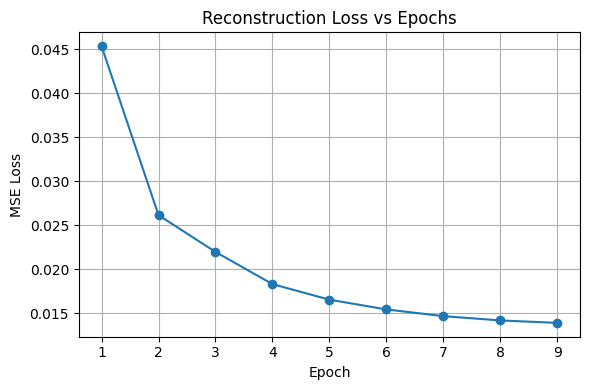

In [17]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o')
plt.title("Reconstruction Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

---
# 5. VISUALIZATION MODULE
Show: Masked Input | Reconstruction | Ground Truth

In [18]:
def get_masked_image(images, mask):
    """
    Grey out the 75% masked patches so we can visualise the masked input.
    images : (B,3,224,224)
    mask   : (B,196)  — 1=masked
    """
    patches = patchify(images)                   # (B,196,768)
    mask_exp = mask.unsqueeze(-1).expand_as(patches)  # (B,196,768)
    masked   = patches * (1 - mask_exp) + 0.5 * mask_exp
    return unpatchify(masked)


@torch.no_grad()
def reconstruct_images(model, images):
    model.eval()
    # Unwrap DataParallel if needed
    m = model.module if isinstance(model, nn.DataParallel) else model

    patches  = patchify(images)
    x        = m.patch_embed(patches)
    x        = x + m.pos_embed

    x_visible, mask, ids_restore = random_masking(x)
    latent   = m.encoder(x_visible)
    x        = m.enc_to_dec(latent)

    B, N, D  = x.shape
    mask_tokens = m.mask_token.expand(B, NUM_PATCHES - N, -1)
    x_       = torch.cat([x, mask_tokens], dim=1)
    x_       = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).expand(-1, -1, D))
    x_       = x_ + m.decoder_pos_embed
    x_       = m.decoder(x_)
    pred     = m.head(x_)                        # (B,196,768)
    recon    = unpatchify(pred)                   # (B,3,224,224)

    masked_img = get_masked_image(images, mask)
    return masked_img, recon

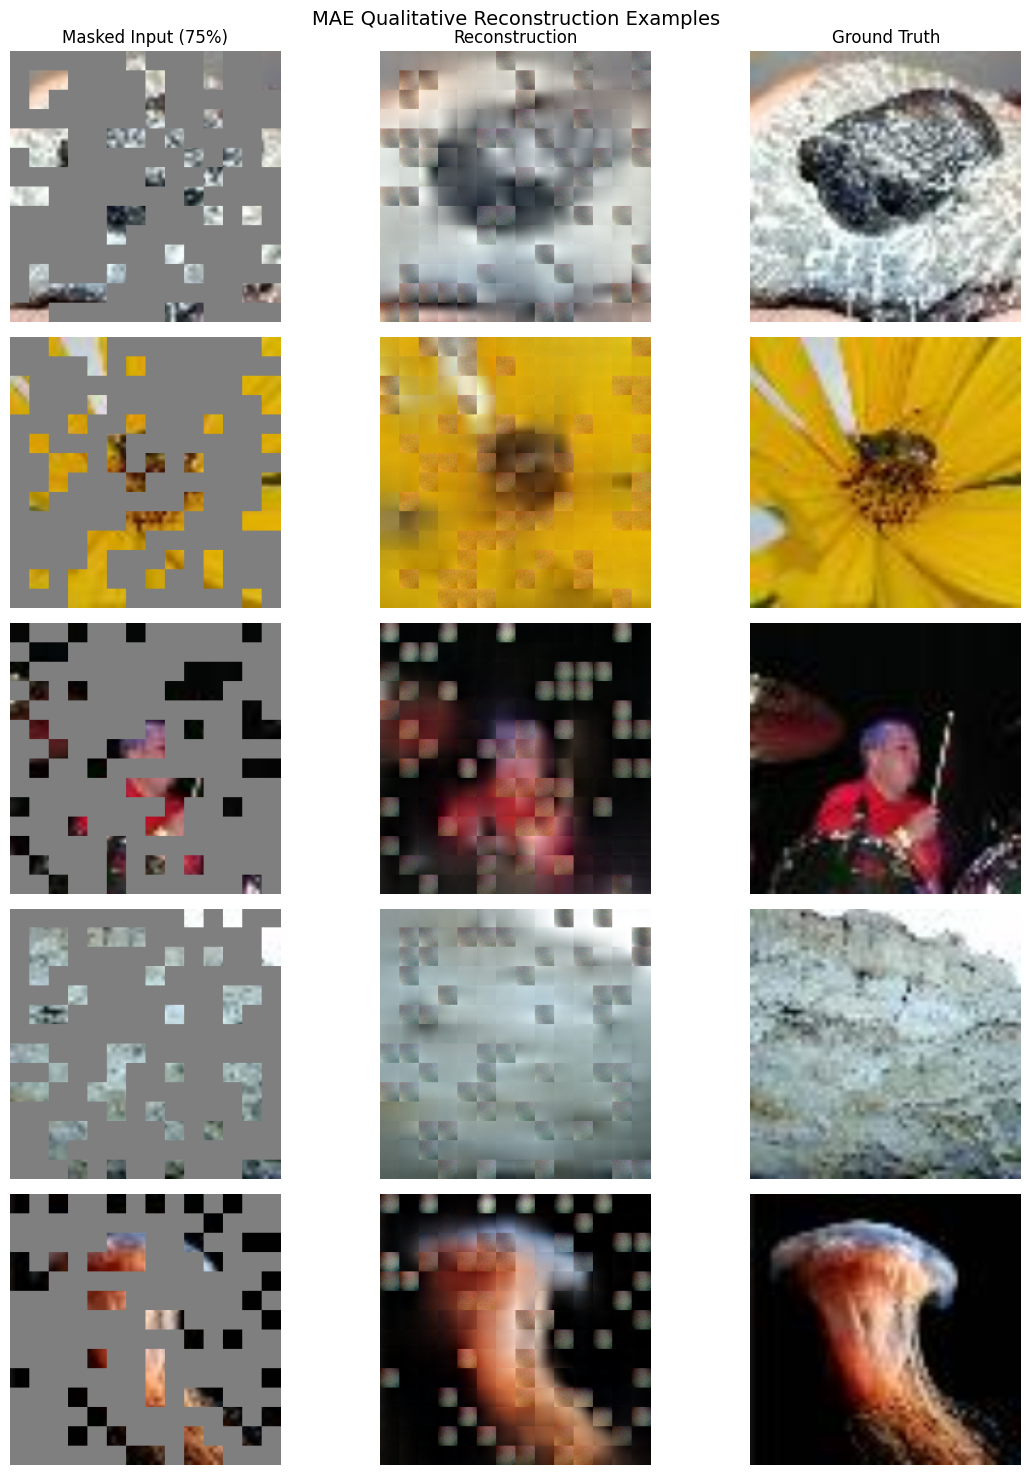

In [19]:
def show_reconstructions(model, dataloader, n=5):
    images, _ = next(iter(dataloader))
    images = images[:n].to(device)

    masked_imgs, recons = reconstruct_images(model, images)

    fig, axes = plt.subplots(n, 3, figsize=(12, 3 * n))
    titles = ["Masked Input (75%)", "Reconstruction", "Ground Truth"]

    for i in range(n):
        for j, img_tensor in enumerate([masked_imgs[i], recons[i], images[i]]):
            img = img_tensor.permute(1, 2, 0).cpu().clamp(0, 1).numpy()
            axes[i, j].imshow(img)
            axes[i, j].axis("off")
            if i == 0:
                axes[i, j].set_title(titles[j], fontsize=12)

    plt.suptitle("MAE Qualitative Reconstruction Examples", fontsize=14)
    plt.tight_layout()
    plt.show()

show_reconstructions(model, dataloader, n=5)

---
# 6. QUANTITATIVE EVALUATION (PSNR & SSIM)

In [20]:
from torchmetrics.image import StructuralSimilarityIndexMeasure

ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)


def compute_psnr(original, reconstructed):
    mse = torch.mean((original - reconstructed) ** 2)
    if mse == 0:
        return 100.0
    psnr = 20 * torch.log10(1.0 / torch.sqrt(mse))
    return psnr.item()


def compute_ssim(original, reconstructed):
    return ssim_metric(
        reconstructed.clamp(0, 1),
        original.clamp(0, 1)
    ).item()

In [21]:
images, _ = next(iter(dataloader))
images    = images[:5].to(device)

_, recons = reconstruct_images(model, images)

psnr_score = compute_psnr(images, recons)
ssim_score = compute_ssim(images, recons)

print(f"PSNR : {psnr_score:.4f} dB")
print(f"SSIM : {ssim_score:.4f}")

PSNR : 16.3990 dB
SSIM : 0.4649


---
# 7. GRADIO APP (Image Upload + Masking Ratio Slider)

In [22]:
import gradio as gr


@torch.no_grad()
def mae_reconstruct(pil_image, mask_ratio):
    """
    Gradio callback.
    pil_image  : PIL.Image uploaded by user
    mask_ratio : float slider (0.5 – 0.9)
    returns    : numpy array (H,W,3) of reconstructed image
    """
    tfm = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor()
    ])
    img = tfm(pil_image).unsqueeze(0).to(device)  # (1,3,224,224)

    m = model.module if isinstance(model, nn.DataParallel) else model
    m.eval()

    patches   = patchify(img)
    x         = m.patch_embed(patches)
    x         = x + m.pos_embed

    x_visible, mask, ids_restore = random_masking(x, mask_ratio)

    latent    = m.encoder(x_visible)
    x         = m.enc_to_dec(latent)

    B, N, D   = x.shape
    mask_tokens = m.mask_token.expand(B, NUM_PATCHES - N, -1)
    x_        = torch.cat([x, mask_tokens], dim=1)
    x_        = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).expand(-1, -1, D))
    x_        = x_ + m.decoder_pos_embed
    x_        = m.decoder(x_)
    pred      = m.head(x_)
    recon     = unpatchify(pred)                  # (1,3,224,224)

    recon_np  = recon[0].permute(1, 2, 0).cpu().clamp(0, 1).numpy()
    return recon_np


interface = gr.Interface(
    fn=mae_reconstruct,
    inputs=[
        gr.Image(type="pil", label="Upload Image"),
        gr.Slider(minimum=0.5, maximum=0.9, value=0.75, step=0.05, label="Masking Ratio")
    ],
    outputs=gr.Image(label="Reconstructed Image"),
    title="Masked Autoencoder — Image Reconstruction",
    description="Upload any image and adjust the masking ratio to see how the MAE reconstructs the missing patches."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://aae28d064aa237af73.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [23]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
